<a href="https://colab.research.google.com/github/mallugze/Time-Series-Demand-Forecasting-System-using-ARIMA-SARIMA-with-Statistical-Validation/blob/main/Time_Series_Demand_Forecasting_System_using_ARIMA_%26_SARIMA_with_Statistical_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')






In [ ]:
df = pd.read_csv('train.csv')

df.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1.0,AUTOMOTIVE,0.0,0.0
1,1,2013-01-01,1.0,BABY CARE,0.0,0.0
2,2,2013-01-01,1.0,BEAUTY,0.0,0.0
3,3,2013-01-01,1.0,BEVERAGES,0.0,0.0
4,4,2013-01-01,1.0,BOOKS,0.0,0.0


In [ ]:
df.shape

(3027387, 6)

In [ ]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [ ]:

df['store_nbr'].unique()[:10]


array([ 1., 10., 11., 12., 13., 14., 15., 16., 17., 18.])

In [ ]:

df['family'].unique()[:10]


array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI'],
      dtype=object)

In [ ]:
df = pd.read_csv('train.csv')

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

df = df.sort_values('date')
df.set_index('date', inplace=True)



In [ ]:
df['store_nbr'].unique()[:10]


array([ 1., 42., 41., 43., 40.,  4., 45., 44., 46., 36.])

In [ ]:
df['family'].unique()[:10]


array(['AUTOMOTIVE', 'CELEBRATION', 'BREAD/BAKERY', 'BOOKS', 'BEVERAGES',
       'BEAUTY', 'BABY CARE', 'SEAFOOD', 'SCHOOL AND OFFICE SUPPLIES',
       'PRODUCE'], dtype=object)

In [ ]:
store_40_auto = df[(df['store_nbr'] == 40) &
                   (df['family'] == 'AUTOMOTIVE')]
store_40_auto = store_40_auto.groupby('date')['sales'].sum()
store_40_auto = store_40_auto.to_frame()
store_40_auto = store_40_auto.asfreq('D')
store_40_auto['sales'] = store_40_auto['sales'].fillna(0)


In [ ]:
store_40_auto.shape


(1688, 1)

In [ ]:
store_40_auto.index.is_unique


True

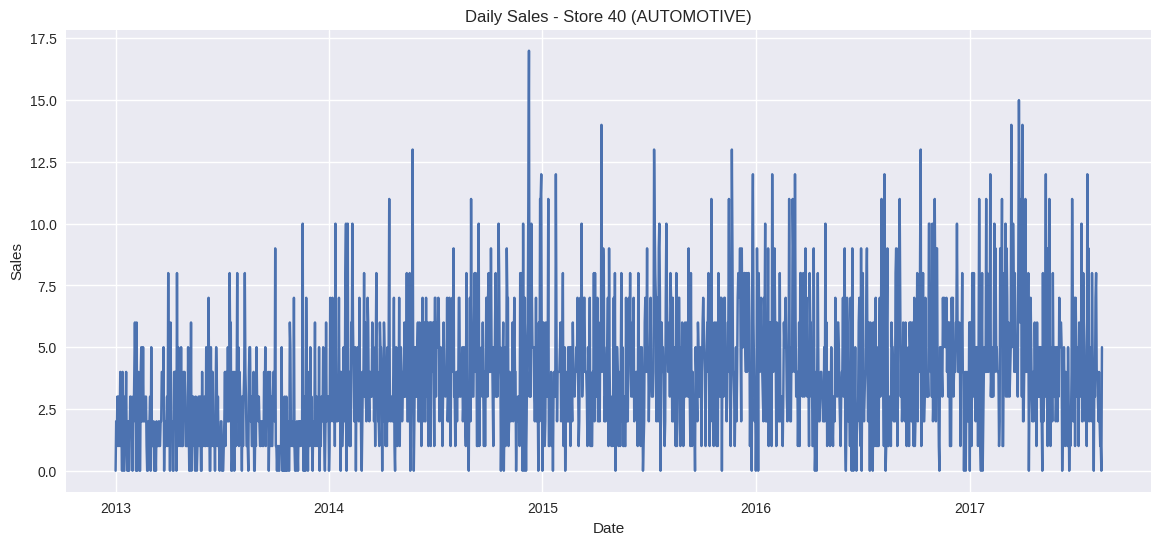

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(store_40_auto['sales'])
plt.title('Daily Sales - Store 40 (AUTOMOTIVE)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


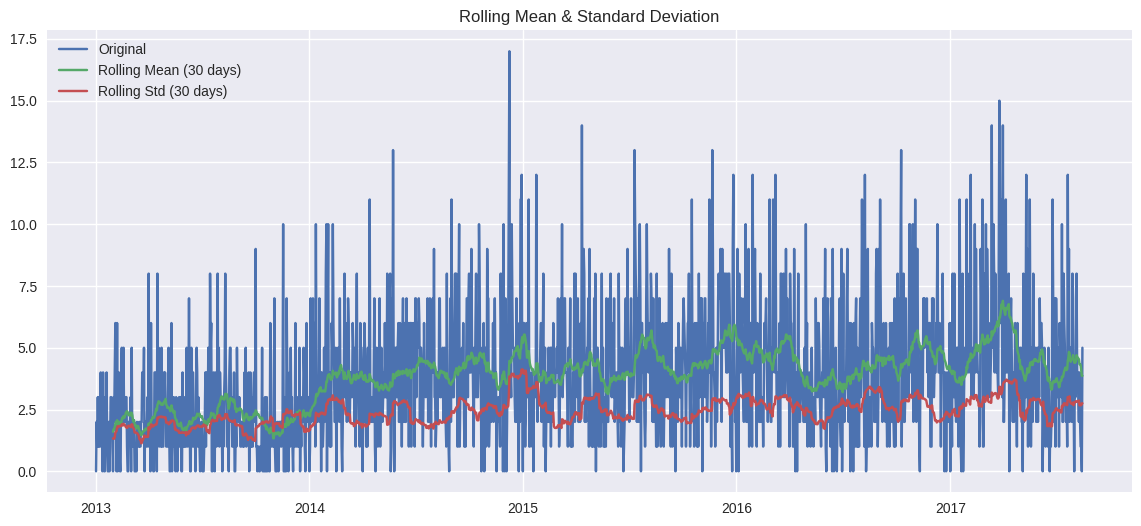

In [ ]:
rolling_mean = store_40_auto['sales'].rolling(window=30).mean()
rolling_std = store_40_auto['sales'].rolling(window=30).std()

plt.figure(figsize=(14,6))
plt.plot(store_40_auto['sales'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (30 days)')
plt.plot(rolling_std, label='Rolling Std (30 days)')
plt.legend()
plt.title('Rolling Mean & Standard Deviation')
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(store_40_auto['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -4.588737430924283
p-value: 0.00013548665290829612
Critical Values:
   1%: -3.43427885313169
   5%: -2.863275365507293
   10%: -2.5676938662645394


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


<Figure size 1400x600 with 0 Axes>

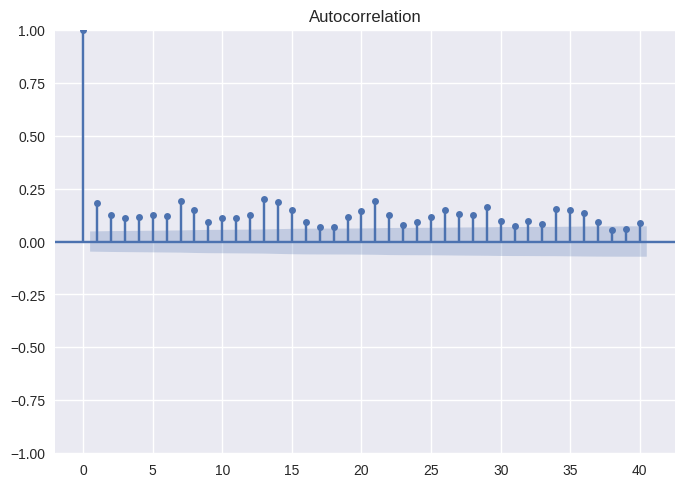

<Figure size 1400x600 with 0 Axes>

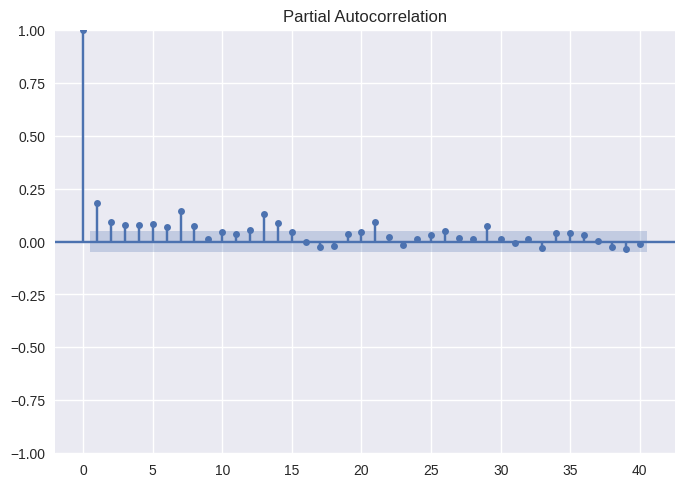

In [ ]:
plt.figure(figsize=(14,6))
plot_acf(store_40_auto['sales'], lags=40)
plt.show()

plt.figure(figsize=(14,6))
plot_pacf(store_40_auto['sales'], lags=40)
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_100 = ARIMA(store_40_auto['sales'], order=(1,0,0))
result_100 = model_100.fit()

result_100.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                 1688
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -4025.775
Date:                Sat, 14 Feb 2026   AIC                           8057.550
Time:                        10:14:59   BIC                           8073.844
Sample:                    01-01-2013   HQIC                          8063.585
                         - 08-15-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8393      0.092     41.765      0.000       3.659       4.019
ar.L1          0.1824      0.022      8.125      0.000       0.138       0.226
sigma2         6.9032      0.235     29.428      0.000       6.443       7.363
===================================================================================
Ljung-Box (L1) (Q):                   0.49   Jarque-Bera (JB):               264.61
Prob(Q):                              0.48   Prob(JB):                         0.00
Heteroskedasticity (H):               1.43   Skew:                             0.88
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
model_001 = ARIMA(store_40_auto['sales'], order=(0,0,1))
result_001 = model_001.fit()

print("AIC (0,0,1):", result_001.aic)


AIC (0,0,1): 8066.738530065236


In [ ]:
model_101 = ARIMA(store_40_auto['sales'], order=(1,0,1))
result_101 = model_101.fit()

print("AIC (1,0,1):", result_101.aic)



AIC (1,0,1): 7923.517858984714


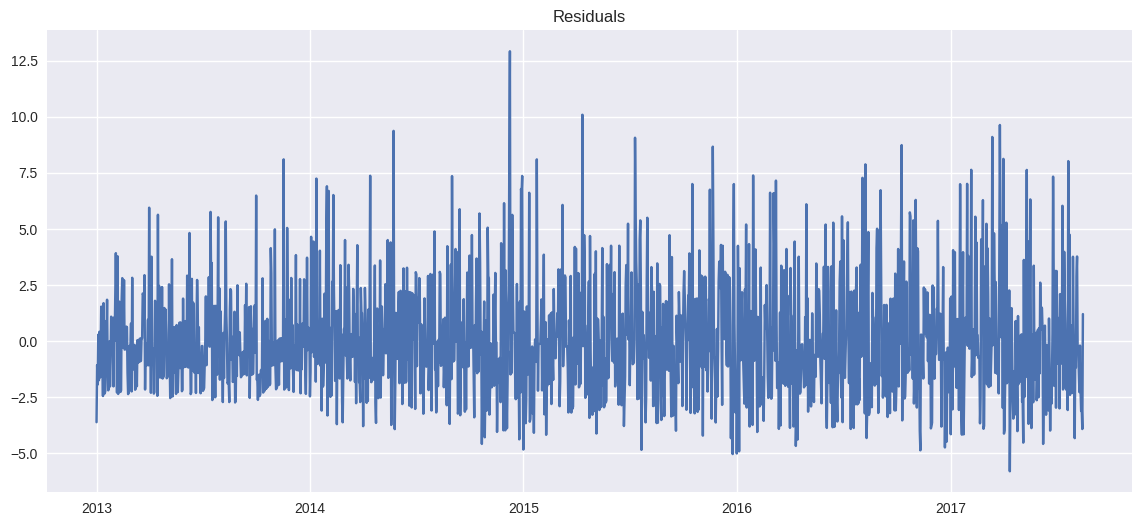

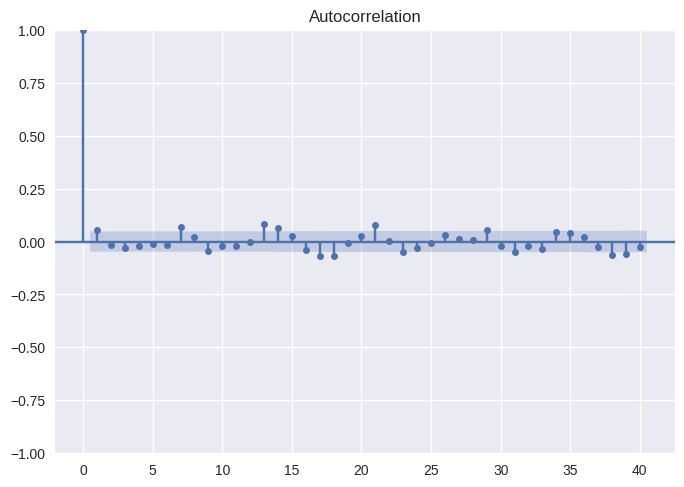

In [ ]:
residuals = result_101.resid

plt.figure(figsize=(14,6))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plot_acf(residuals, lags=40)
plt.show()


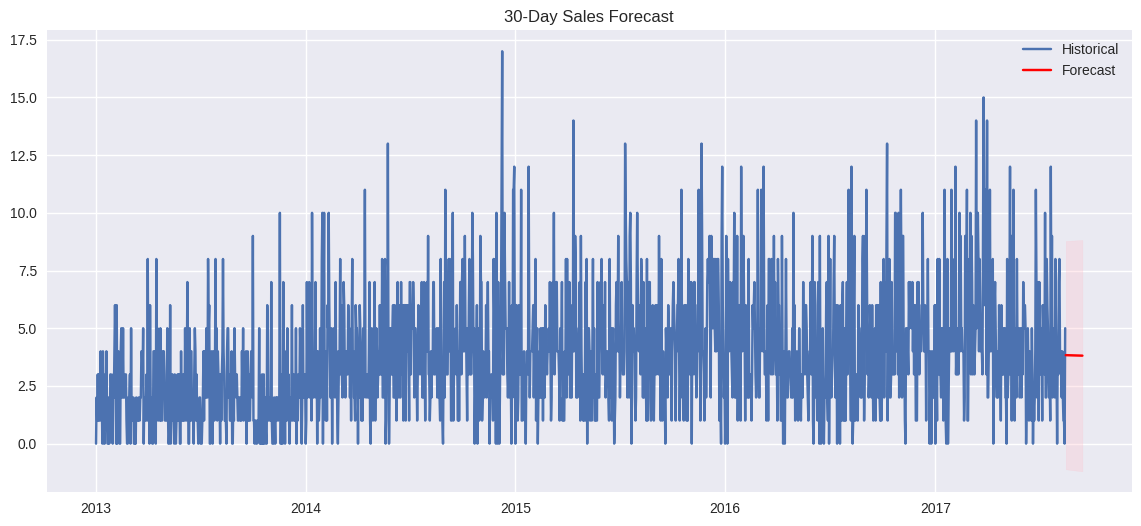

In [ ]:
forecast = result_101.get_forecast(steps=30)

forecast_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

plt.figure(figsize=(14,6))
plt.plot(store_40_auto['sales'], label='Historical')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("30-Day Sales Forecast")
plt.show()
